# Task-routed: interference exploration (experimental plots)

This notebook loads the **same runs and metrics** as `nb_task_routed_init_scale_geometry_transfer.ipynb` but focuses on **visualizing interference** beyond the single scalar **transfer** metric (`initial B − final A1`).

**Why:** Transfer-only plots capture *switch cost at the A→B boundary*; interference often also shows up as **post-B forgetting / A2 retest** relative to end-of-A1 performance.

**Metrics tried here (participant-level, then aggregated):**
- **Transfer** (existing): `error_diff = mean(B first 6 winter trials) − mean(A1 last 6 winter trials)`
- **Retest gap**: `mean(A2 winter trials) − final_A1` (negative ⇒ worse after A2 than at end of A1)
- **B-phase drift**: `mean(B last 6) − mean(B first 6)`
- **Phase means** from `accuracy_df` (coarse summary across all trials in phase)

Edit/add cells freely — this is an exploration sandbox.

In [1]:
# 1. Setup (aligned with task-routed init-scale notebook)

import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SIMILARITY_ORDER = ["same", "near", "far"]
SIMILARITY_PALETTE = {"same": "green", "near": "orange", "far": "blue"}
INIT_SCALE_ORDER = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
SPARSITY_ORDER = ["no_comms", "0.1", "0.3", "0.5", "0.7", "0.9", "1.0", "single_module"]

project_root = Path(os.getcwd()).resolve()
while not (project_root / "a1b2").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Project root (containing a1b2) not found.")
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id
from a1b2.analysis import transfer_interference as ann

data_folder = project_root / "data"
sim_folder = data_folder / "simulations"
config_path = project_root / "a1b2" / "models" / "experiments.json"
with open(config_path, "r") as f:
    settings = json.load(f)

print("Project root:", project_root)
print("Simulations folder:", sim_folder)

Project root: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular
Simulations folder: /home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/a1b2_modular/data/simulations


In [2]:
# 2. Select runs (same logic as nb_task_routed_init_scale_geometry_transfer: task-routed two-module + single_module baseline)

TARGET_ARCH = "two_module_rnn"
TARGET_SINGLE_ARCH = "single_module_rnn"
TARGET_DIM_HIDDEN = 25
TARGET_NB_STEPS = 2
TARGET_ROUTING = "task_routed"
TARGET_COMMON_READOUT = True
TARGET_COMMON_INPUT = False


def is_task_routed_init_scale(c):
    arch = c.get("arch")
    if arch == TARGET_ARCH:
        if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
            return False
        if c.get("nb_steps", 1) != TARGET_NB_STEPS:
            return False
        if c.get("input_routing", "shared") != TARGET_ROUTING:
            return False
        if c.get("common_readout", True) is not TARGET_COMMON_READOUT:
            return False
        if c.get("common_input", False) is not TARGET_COMMON_INPUT:
            return False
        return True
    if arch == TARGET_SINGLE_ARCH:
        if c.get("dim_hidden") != TARGET_DIM_HIDDEN:
            return False
        if c.get("nb_steps", 1) != TARGET_NB_STEPS:
            return False
        return True
    return False


selected = [c for c in settings["conditions"] if is_task_routed_init_scale(c)]
rows = []
for c in selected:
    init_scale = c.get("init_scale", None)
    if init_scale is None:
        init_scale = 1.0
    run_id = build_run_id(c)
    path = sim_folder / run_id
    if c.get("arch") == TARGET_SINGLE_ARCH:
        sp_label = "single_module"
        sp_val = np.nan
    else:
        sp = c.get("sparsity", 1.0)
        if sp == 0 or "no_comms" in c.get("name", ""):
            sp_label = "no_comms"
        else:
            sp_float = float(sp)
            sp_label = "1.0" if np.isclose(sp_float, 1.0) else str(sp_float)
        sp_val = float(sp)
    rows.append({
        "name": c.get("name"),
        "run_id": run_id,
        "arch": c.get("arch"),
        "init_scale": float(init_scale),
        "sparsity": sp_val,
        "sparsity_label": sp_label,
        "path_exists": path.exists(),
        "path": str(path),
    })

run_table = pd.DataFrame(rows)
if not run_table.empty:
    run_table["sparsity_label"] = pd.Categorical(run_table["sparsity_label"], categories=SPARSITY_ORDER, ordered=True)
    run_table = run_table.sort_values(["sparsity_label", "init_scale", "name"]).reset_index(drop=True)
display(run_table)
valid = run_table[run_table["path_exists"]].copy()
print("Selected:", len(run_table), "| With folder:", len(valid))

,name,run_id,arch,init_scale,sparsity,sparsity_label,path_exists,path
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.01,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
1,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.10,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.30,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
3,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.50,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
4,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.70,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
5,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn_25_task_routed_no_comms_nb2_ini...,two_module_rnn,0.90,0.0,no_comms,False,/home/kat/workspace/Structure-Function-Analysi...
6,two_module_rnn_25_task_routed_no_comms_nb2,two_module_rnn_25_task_routed_no_comms_nb2_nb2...,two_module_rnn,1.00,0.0,no_comms,True,/home/kat/workspace/Structure-Function-Analysi...
7,two_module_rnn_25_task_routed_sp01_nb2_init0.01,two_module_rnn_25_task_routed_sp01_nb2_init0.0...,two_module_rnn,0.01,0.1,0.1,True,/home/kat/workspace/Structure-Function-Analysi...
8,two_module_rnn_25_task_routed_sp01_nb2_init0.1,two_module_rnn_25_task_routed_sp01_nb2_init0.1...,two_module_rnn,0.10,0.1,0.1,True,/home/kat/workspace/Structure-Function-Analysi...
9,two_module_rnn_25_task_routed_sp01_nb2_init0.3,two_module_rnn_25_task_routed_sp01_nb2_init0.3...,two_module_rnn,0.30,0.1,0.1,False,/home/kat/workspace/Structure-Function-Analysi...


Selected: 56 | With folder: 46


In [ ]:
# 3. Load ANN data (same as main notebook; skip broken folders)
# took 23 mins to load

all_ann_data = {}
failed_runs = []
for _, row in valid.iterrows():
    run_id = row["run_id"]
    path = Path(row["path"])
    try:
        ann_data = ann.load_ann_data(str(path), load_rnn_extra=True)
    except Exception as e:
        failed_runs.append({"run_id": run_id, "path": str(path), "error": f"{type(e).__name__}: {e}"})
        continue
    if (
        len(ann_data.get("same", [])) > 0
        and len(ann_data.get("near", [])) > 0
        and len(ann_data.get("far", [])) > 0
    ):
        all_ann_data[run_id] = {
            "data": ann_data,
            "init_scale": row["init_scale"],
            "sparsity": row["sparsity"],
            "sparsity_label": row["sparsity_label"],
        }

run_labels = list(all_ann_data.keys())
print("Loaded", len(run_labels), "runs with same/near/far.")
if failed_runs:
    print("Skipped:", len(failed_runs))
    display(pd.DataFrame(failed_runs))

Loaded 45 runs with same/near/far.


In [4]:
# 4. Same per-participant metrics as main notebook (transfer, accuracy, loss, representation)

transfer_records = []
accuracy_records = []
loss_records = []
rep_records = []

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    ann_data = bundle["data"]
    sparsity = bundle["sparsity"]
    sp_label = bundle["sparsity_label"]
    init_scale = bundle["init_scale"]

    for cond_name, entries in ann_data.items():
        for entry in entries:
            pid = str(entry["participant"])
            acc = np.asarray(entry["accuracy"])
            if acc.ndim == 3:
                cond_idx = ["same", "near", "far"].index(cond_name) if cond_name in ["same", "near", "far"] else 0
                acc_cond = acc[cond_idx]
            else:
                acc_cond = acc
                cond_idx = 0

            if acc_cond.ndim >= 2 and acc_cond.shape[0] >= 2:
                A1_acc = acc_cond[0, 1::2] if acc_cond.ndim == 2 else np.asarray(acc_cond[0]).flatten()[1::2]
                B_acc = acc_cond[1, 1::2] if acc_cond.ndim == 2 else np.asarray(acc_cond[1]).flatten()[1::2]
                if len(A1_acc) >= 6 and len(B_acc) >= 6:
                    final_A1 = float(np.mean(A1_acc[-6:]))
                    init_B = float(np.mean(B_acc[:6]))
                    transfer_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity": sparsity,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "participant": pid,
                        "error_diff": init_B - final_A1,
                    })

            if acc_cond.size > 0:
                n_ph = acc_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = ["post_A", "post_B", "post_A2"][ph]
                    mean_acc = float(np.nanmean(acc_cond[ph]))
                    accuracy_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "phase": phase_name,
                        "participant": pid,
                        "mean_accuracy": mean_acc,
                    })

            losses = entry.get("losses")
            if losses is not None:
                loss_arr = np.asarray(losses)
                if loss_arr.ndim == 3:
                    loss_cond = loss_arr[cond_idx]
                else:
                    loss_cond = loss_arr
                n_ph = loss_cond.shape[0]
                for ph in range(min(3, n_ph)):
                    phase_name = ["post_A", "post_B", "post_A2"][ph]
                    mean_loss = float(np.nanmean(loss_cond[ph]))
                    loss_records.append({
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "phase": phase_name,
                        "participant": pid,
                        "mean_loss": mean_loss,
                    })

            for phase_idx, phase_name in [(0, "post_A"), (1, "post_B"), (2, "post_A2")]:
                if f"hiddens_post_phase_{phase_idx}" not in entry:
                    continue
                for path in ("combined", "core", "comms"):
                    try:
                        hids = ann._get_last_step_geometry_hids(entry, phase_idx, path=path)
                    except (KeyError, ValueError):
                        continue
                    metrics = ann.compute_state_representation_metrics(
                        hids, variance_thresholds=(0.95, 0.99), top_k=2
                    )
                    row = {
                        "run_id": run_id,
                        "init_scale": init_scale,
                        "sparsity_label": sp_label,
                        "condition": cond_name,
                        "participant": pid,
                        "phase": phase_name,
                        "pathway": path,
                        "var_topk": metrics["var_topk"],
                    }
                    for thr, n in metrics["n_components"].items():
                        row[f"n_pcs_{int(thr*100)}"] = n
                    rep_records.append(row)

transfer_df = pd.DataFrame(transfer_records)
accuracy_df = pd.DataFrame(accuracy_records)
loss_df = pd.DataFrame(loss_records)
rep_df = pd.DataFrame(rep_records)
print(transfer_df.shape, accuracy_df.shape, loss_df.shape, rep_df.shape)

(10957, 7) (32871, 7) (32871, 7) (84111, 10)


## A. Extended interference scalars (participant-level)

Same winter-trial slicing as transfer (`[1::2]` on each phase), block size 6 where applicable.

In [5]:
interference_records = []

for run_id in run_labels:
    bundle = all_ann_data[run_id]
    ann_data = bundle["data"]
    sp_label = bundle["sparsity_label"]
    init_scale = bundle["init_scale"]
    sparsity = bundle["sparsity"]

    for cond_name, entries in ann_data.items():
        for entry in entries:
            pid = str(entry["participant"])
            acc = np.asarray(entry["accuracy"])
            if acc.ndim == 3:
                cond_idx = ["same", "near", "far"].index(cond_name) if cond_name in ["same", "near", "far"] else 0
                acc_cond = acc[cond_idx]
            else:
                acc_cond = acc

            if acc_cond.ndim < 2 or acc_cond.shape[0] < 3:
                continue
            A1 = acc_cond[0, 1::2]
            B = acc_cond[1, 1::2]
            A2 = acc_cond[2, 1::2]
            if len(A1) < 6 or len(B) < 6 or len(A2) < 1:
                continue
            final_A1 = float(np.mean(A1[-6:]))
            init_B = float(np.mean(B[:6]))
            final_B = float(np.mean(B[-6:]))
            mean_A2 = float(np.mean(A2))
            last6_A2 = float(np.mean(A2[-6:])) if len(A2) >= 6 else mean_A2

            interference_records.append({
                "run_id": run_id,
                "init_scale": init_scale,
                "sparsity": sparsity,
                "sparsity_label": sp_label,
                "condition": cond_name,
                "participant": pid,
                "transfer_error_diff": init_B - final_A1,
                "retest_gap_meanA2": mean_A2 - final_A1,
                "retest_gap_last6A2": last6_A2 - final_A1,
                "B_drift": final_B - init_B,
                "final_A1": final_A1,
                "mean_A2": mean_A2,
            })

interf_df = pd.DataFrame(interference_records)
print(interf_df.shape)
display(interf_df.head())

(10957, 12)


,run_id,init_scale,sparsity,sparsity_label,condition,participant,transfer_error_diff,retest_gap_meanA2,retest_gap_last6A2,B_drift,final_A1,mean_A2
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.01,0.0,no_comms,same,sim_study2_same_sub9,-0.380670,0.012763,0.012763,0.510956,0.869714,0.882477
1,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.01,0.0,no_comms,same,sim_study2_same_sub32,-0.330740,-0.030501,-0.030501,0.487269,0.843471,0.812969
2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.01,0.0,no_comms,same,sim_study1_same_sub9,-0.352009,-0.027706,-0.027706,0.515419,0.836590,0.808884
3,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.01,0.0,no_comms,same,sim_study1_same_sub40,-0.399541,-0.049297,-0.049297,0.518219,0.881322,0.832025
4,two_module_rnn_25_task_routed_no_comms_nb2_ini...,0.01,0.0,no_comms,same,sim_study1_same_sub44,-0.402141,0.112746,0.112746,0.554288,0.847853,0.960598


## B. Plot: transfer vs retest gap (per participant)

Each point is one participant. **Retest gap** = `mean(A2 winter) − final_A1`. Negative values ⇒ A2 worse than end of A1 (forgetting / interference on A).

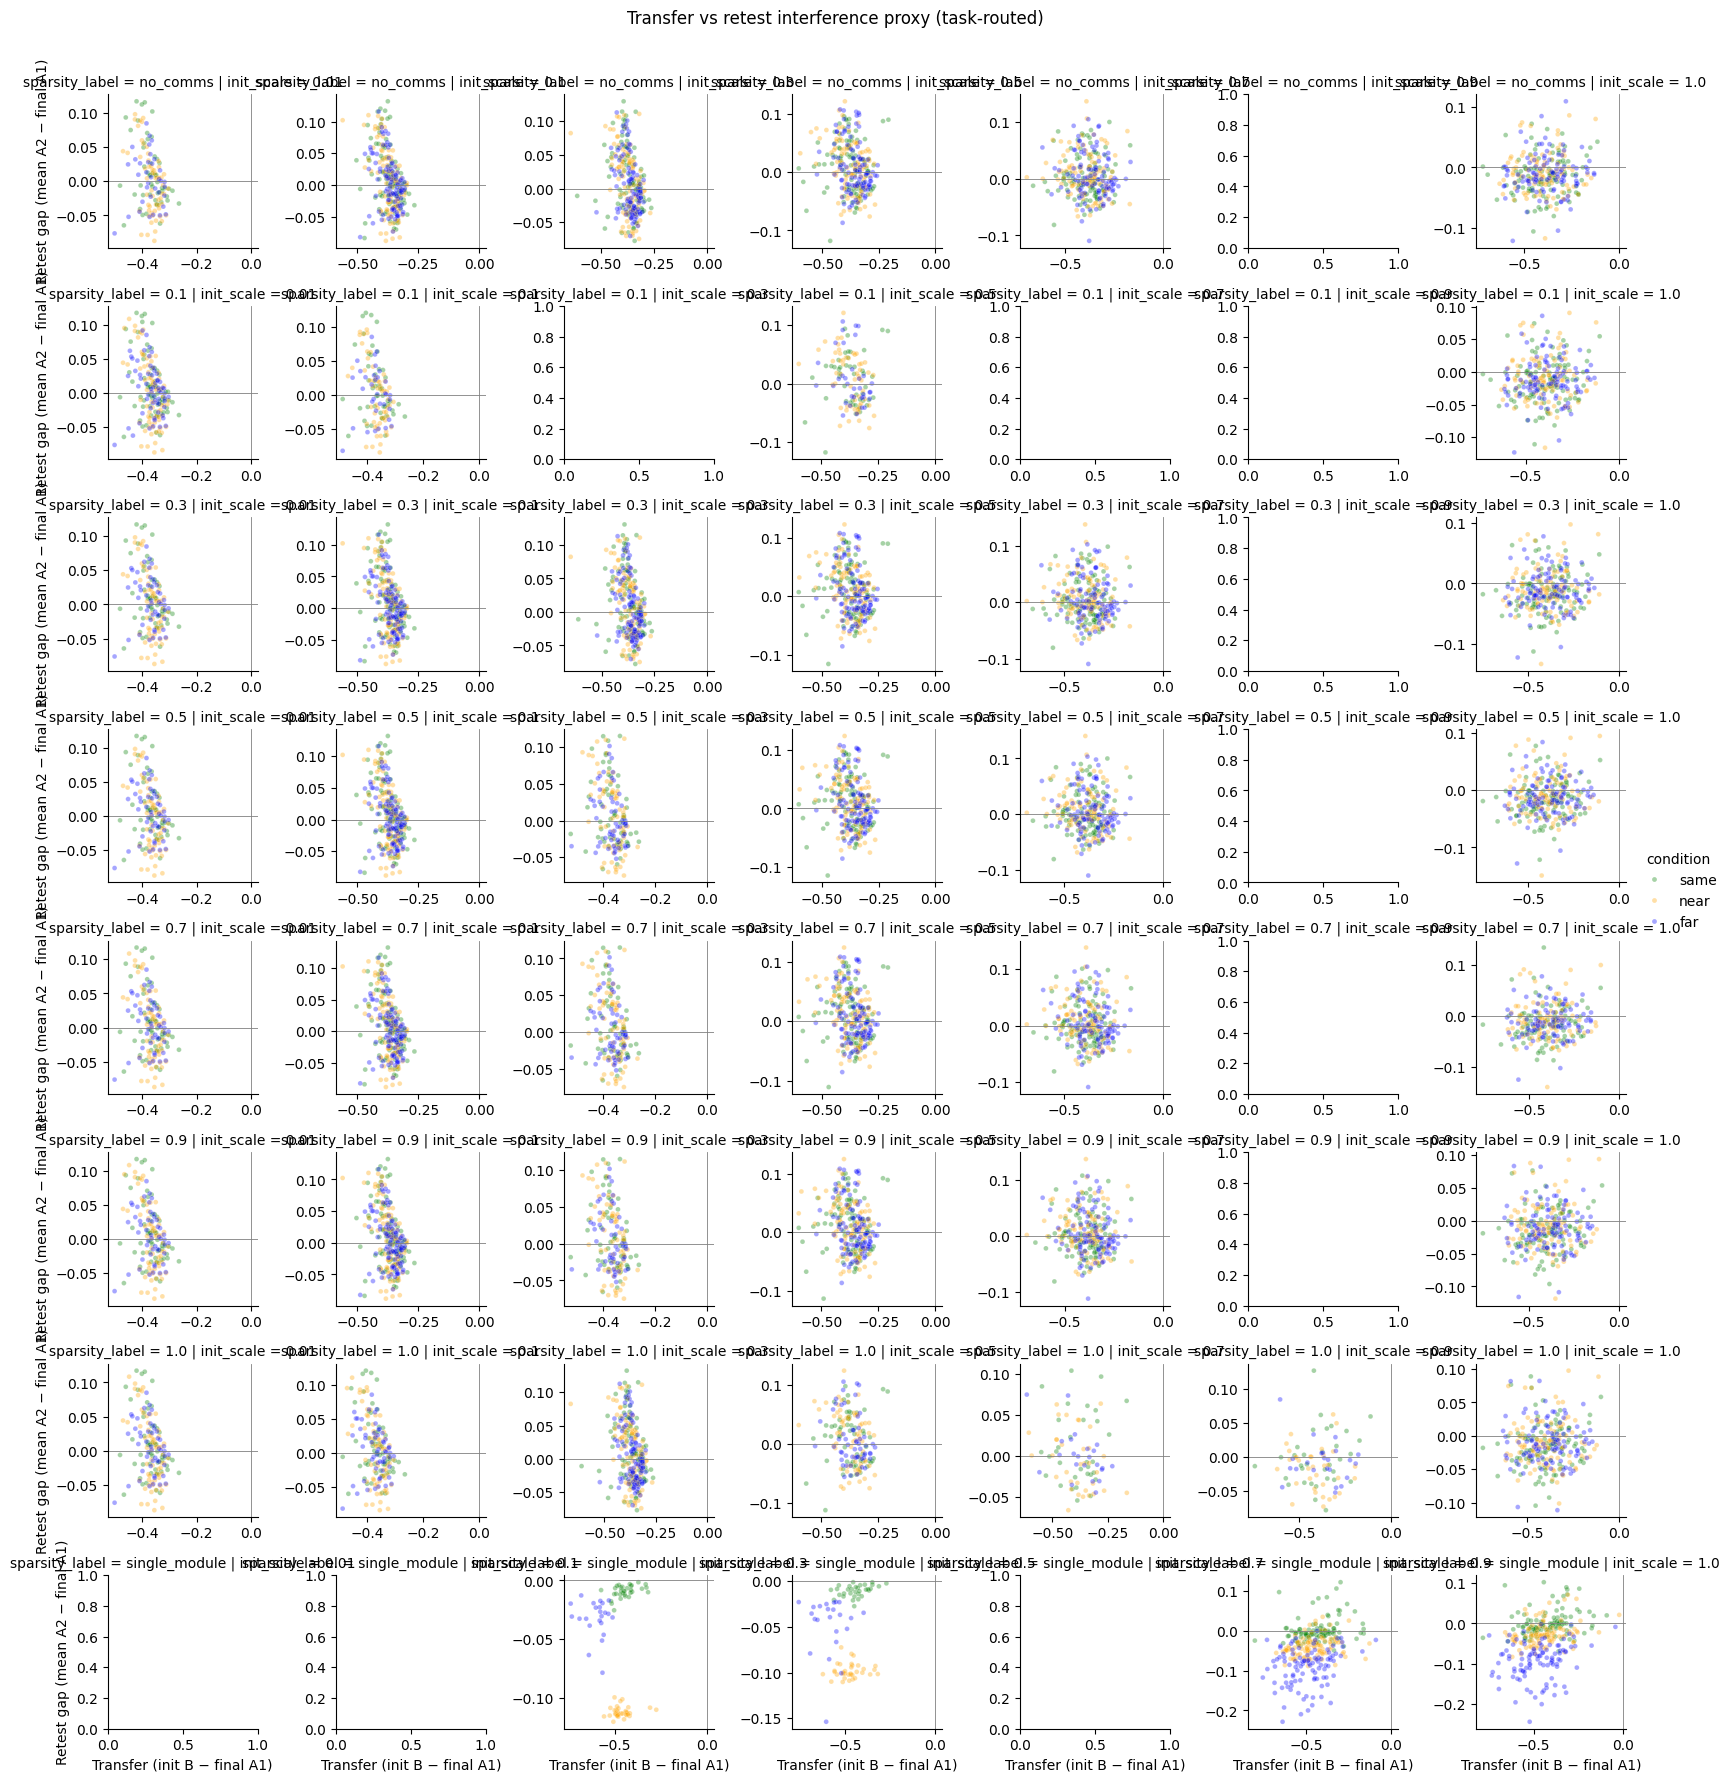

In [6]:
if interf_df.empty:
    print("No interference dataframe.")
else:
    g = sns.relplot(
        data=interf_df,
        x="transfer_error_diff",
        y="retest_gap_meanA2",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        col="init_scale",
        col_order=INIT_SCALE_ORDER,
        row="sparsity_label",
        row_order=SPARSITY_ORDER,
        alpha=0.35,
        s=12,
        height=2.2,
        facet_kws={"sharex": False, "sharey": False},
    )
    for ax in g.axes.flat:
        if ax is not None:
            ax.axhline(0, color="gray", lw=0.6)
            ax.axvline(0, color="gray", lw=0.6)
    g.set_axis_labels("Transfer (init B − final A1)", "Retest gap (mean A2 − final A1)")
    g.fig.suptitle("Transfer vs retest interference proxy (task-routed)", y=1.01)
    plt.tight_layout()
    plt.show()

## C. Plot: retest gap across init_scale (mirror Section 5 style)

Directly comparable to transfer facet grid; shows **A2 vs end-A1** instead of **start-B vs end-A1**.

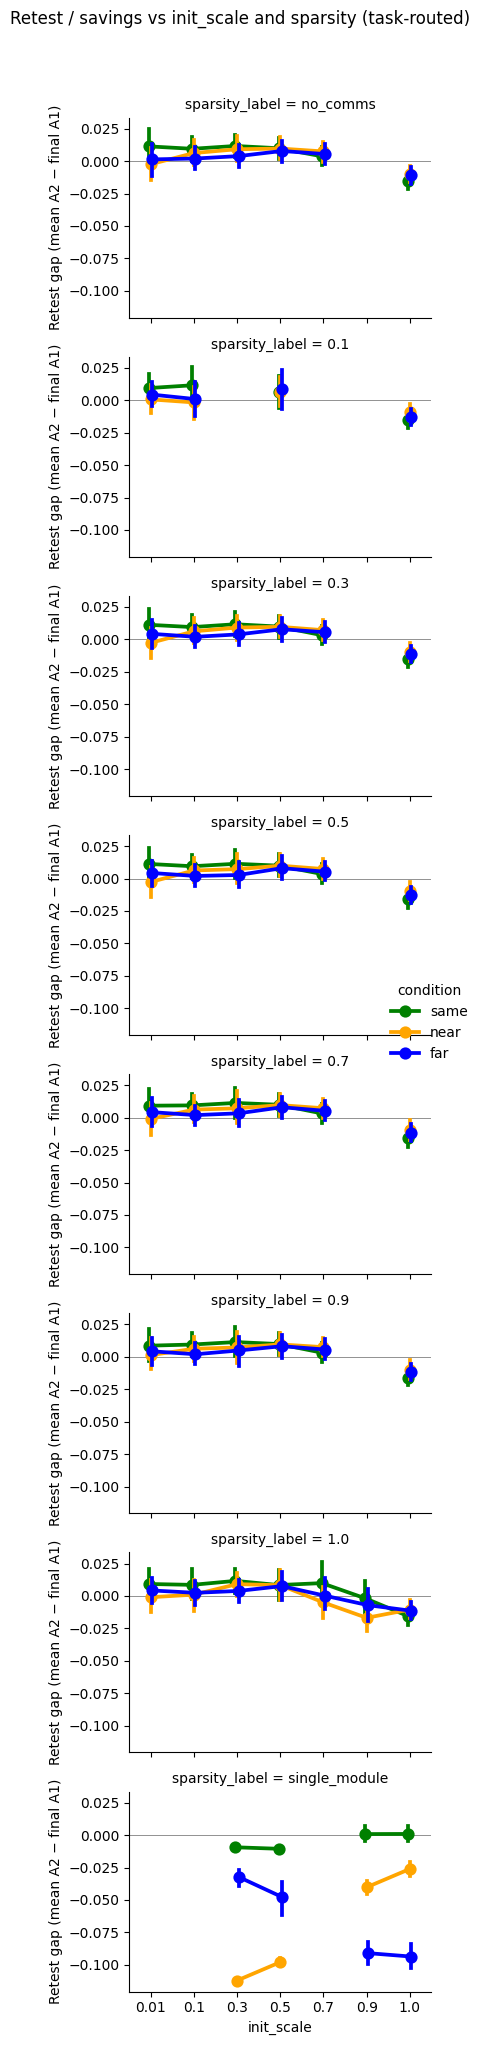

In [7]:
if not interf_df.empty:
    g = sns.catplot(
        data=interf_df,
        x="init_scale",
        y="retest_gap_meanA2",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        row="sparsity_label",
        kind="point",
        dodge=True,
        order=INIT_SCALE_ORDER,
        hue_order=SIMILARITY_ORDER,
        row_order=SPARSITY_ORDER,
        height=2.5,
        aspect=1.3,
    )
    g.set_axis_labels("init_scale", "Retest gap (mean A2 − final A1)")
    for ax in g.axes.flat:
        if ax is not None:
            ax.axhline(0, color="gray", lw=0.6, zorder=0)
    g.fig.suptitle("Retest / savings vs init_scale and sparsity (task-routed)", y=1.02)
    plt.tight_layout()
    plt.show()

## D. Heatmap: mean retest gap by sparsity × init_scale

One heatmap per similarity condition; values are **mean** `retest_gap_meanA2` over participants.

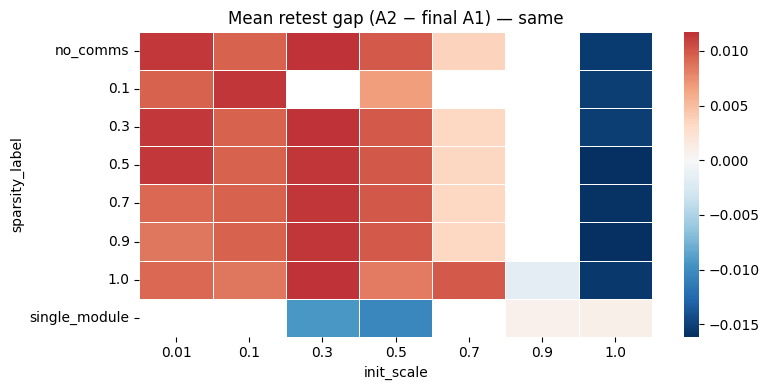

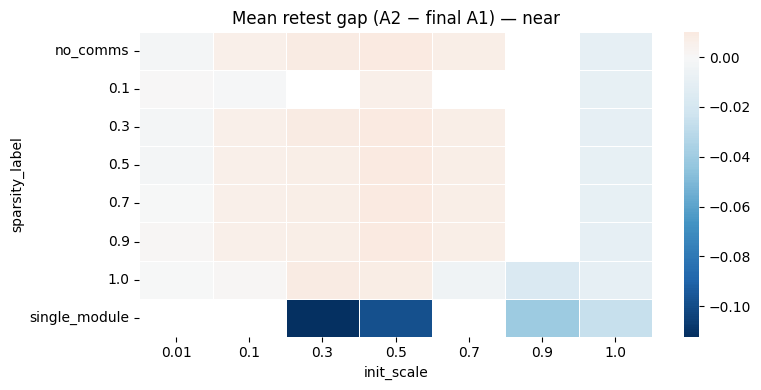

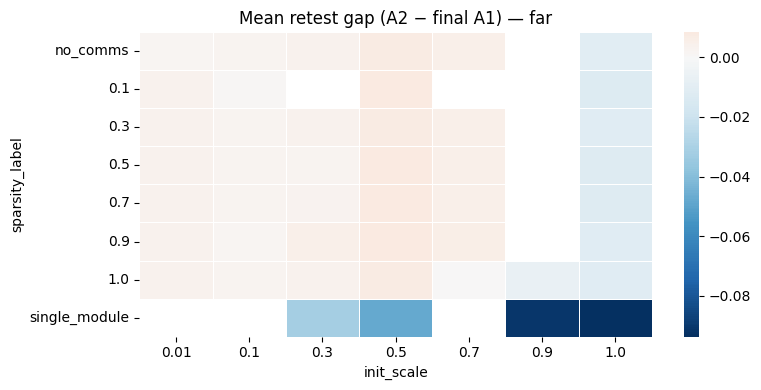

In [8]:
if interf_df.empty:
    print("No data.")
else:
    for cond in SIMILARITY_ORDER:
        sub = interf_df[interf_df["condition"] == cond]
        if sub.empty:
            continue
        pivot = (
            sub.groupby(["sparsity_label", "init_scale"], as_index=False)["retest_gap_meanA2"]
            .mean()
            .pivot(index="sparsity_label", columns="init_scale", values="retest_gap_meanA2")
        )
        pivot = pivot.reindex(index=SPARSITY_ORDER, columns=INIT_SCALE_ORDER)
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.heatmap(pivot, ax=ax, cmap="RdBu_r", center=0, linewidths=0.5)
        ax.set_title(f"Mean retest gap (A2 − final A1) — {cond}")
        plt.tight_layout()
        plt.show()

## E. Phase accuracy profile (coarse): post_A → post_B → post_A2

Uses **phase-wide mean** from `accuracy_df` (all trials in phase). Less aligned with winter-only Holton slicing but useful for shape.

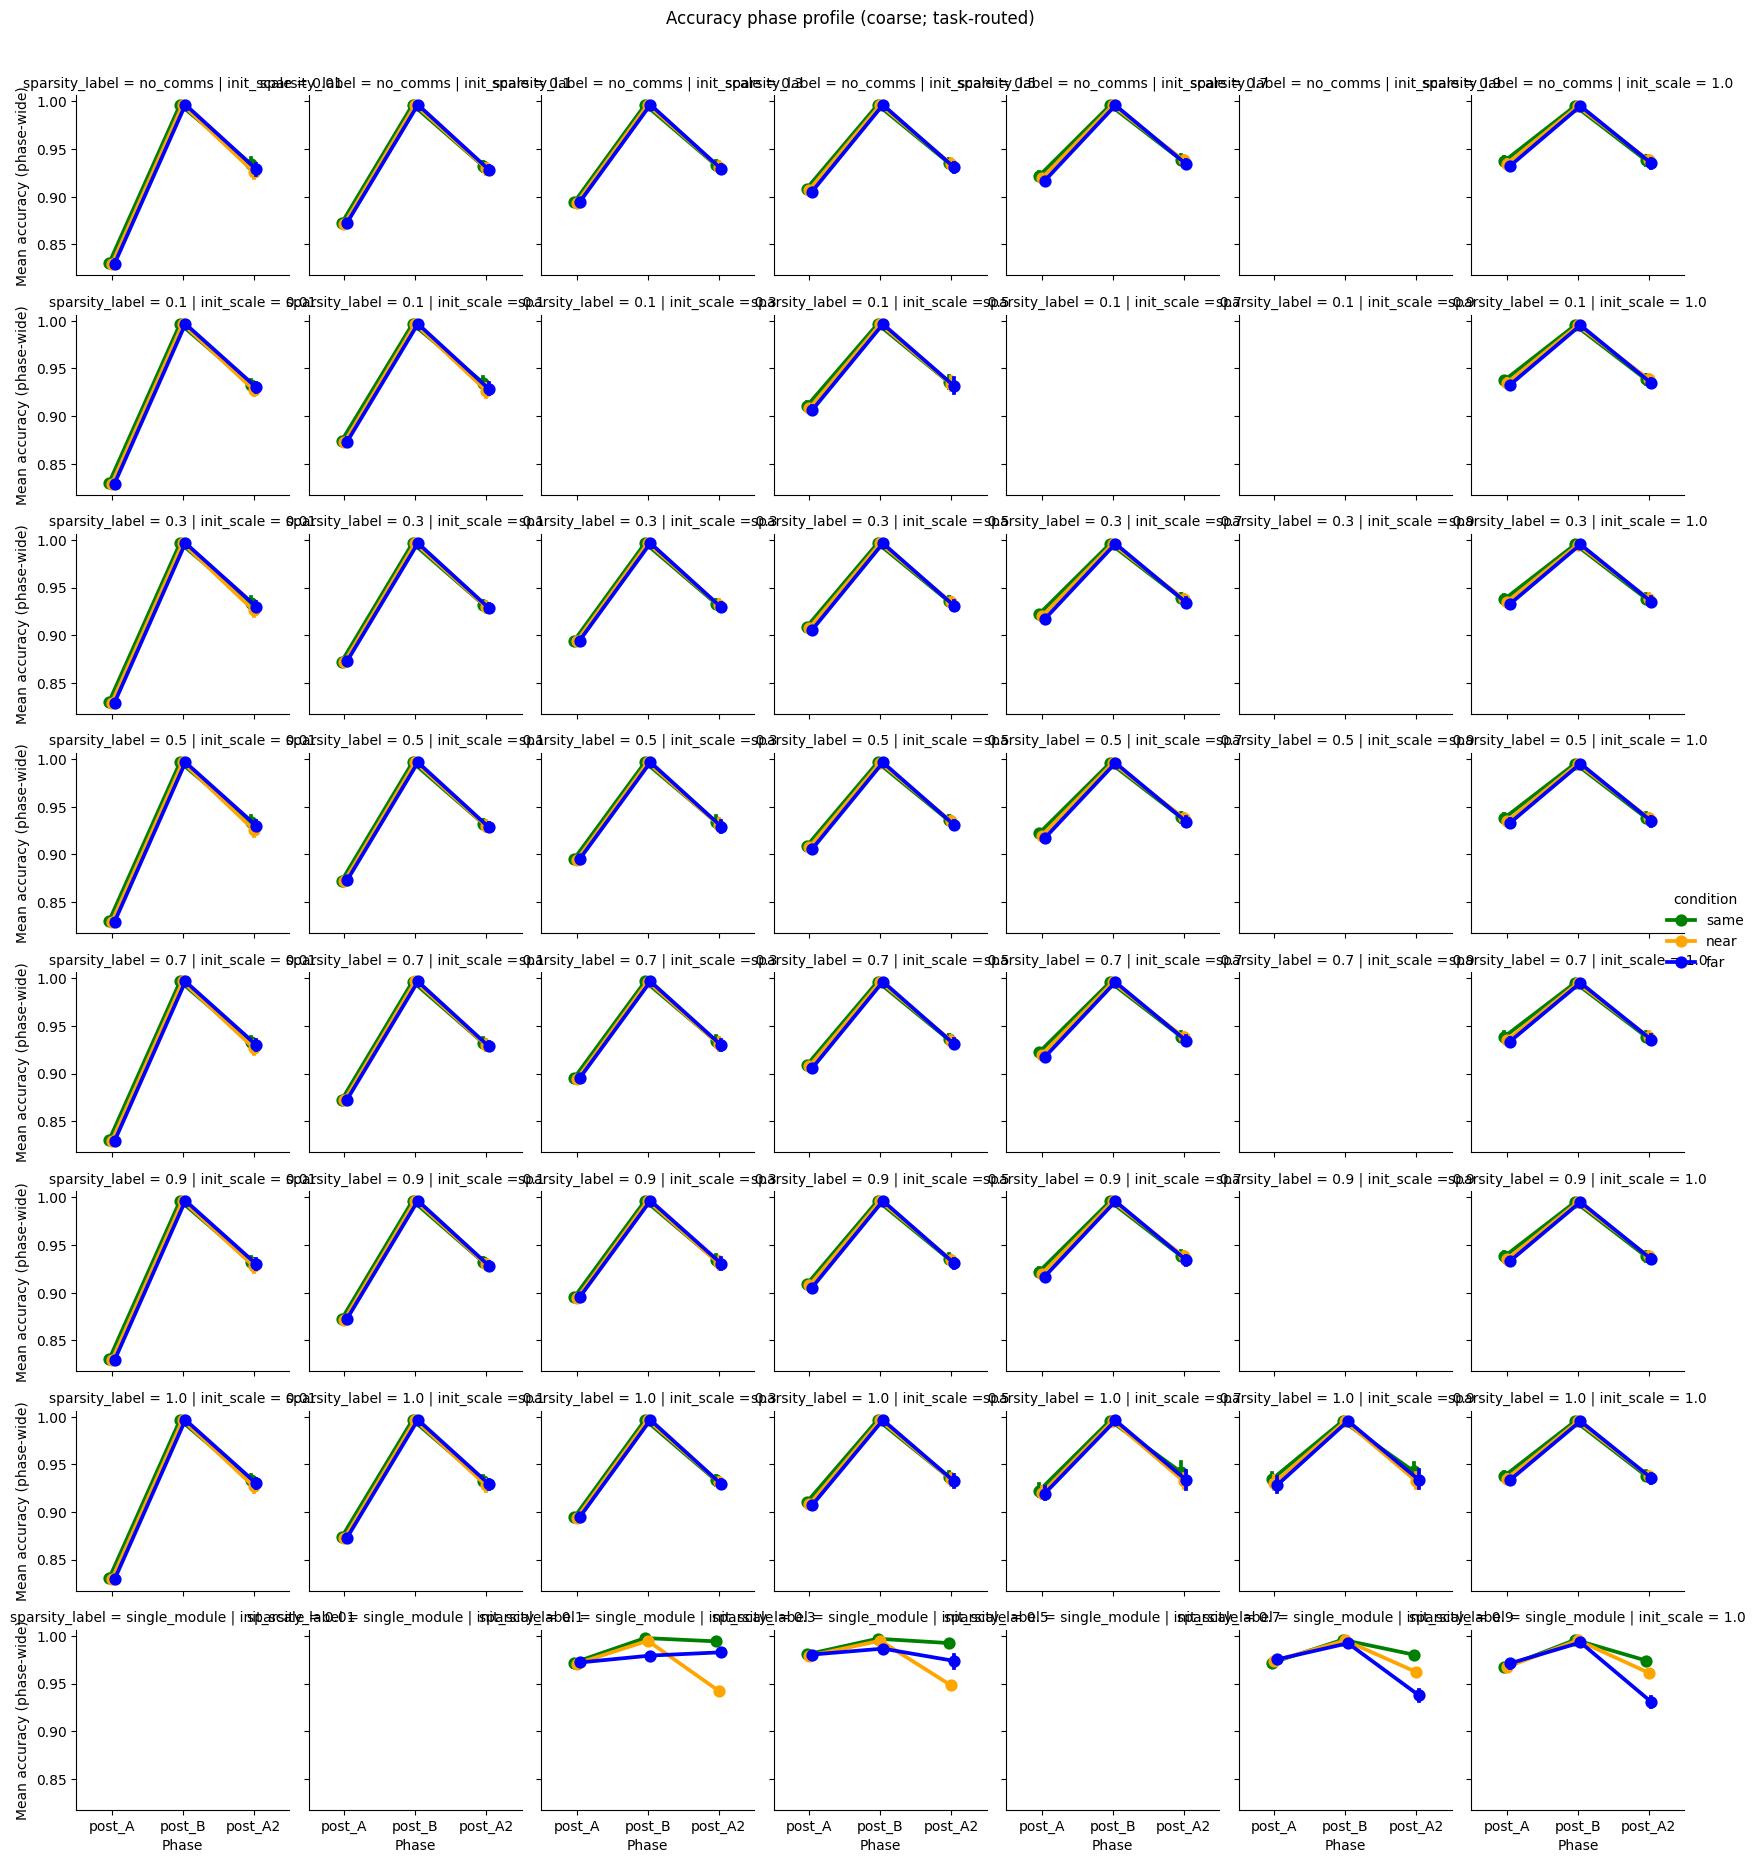

In [9]:
if accuracy_df.empty:
    print("No accuracy_df.")
else:
    phase_order = ["post_A", "post_B", "post_A2"]
    g = sns.catplot(
        data=accuracy_df,
        x="phase",
        y="mean_accuracy",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        col="init_scale",
        col_order=INIT_SCALE_ORDER,
        row="sparsity_label",
        row_order=SPARSITY_ORDER,
        kind="point",
        dodge=True,
        order=phase_order,
        hue_order=SIMILARITY_ORDER,
        height=2.3,
        aspect=1.0,
    )
    g.set_axis_labels("Phase", "Mean accuracy (phase-wide)")
    g.fig.suptitle("Accuracy phase profile (coarse; task-routed)", y=1.01)
    plt.tight_layout()
    plt.show()

## F. Optional: correlation transfer vs retest (per run × condition)

Aggregates participants within each configuration; useful to see whether high switch-cost runs also show strong A2 forgetting.

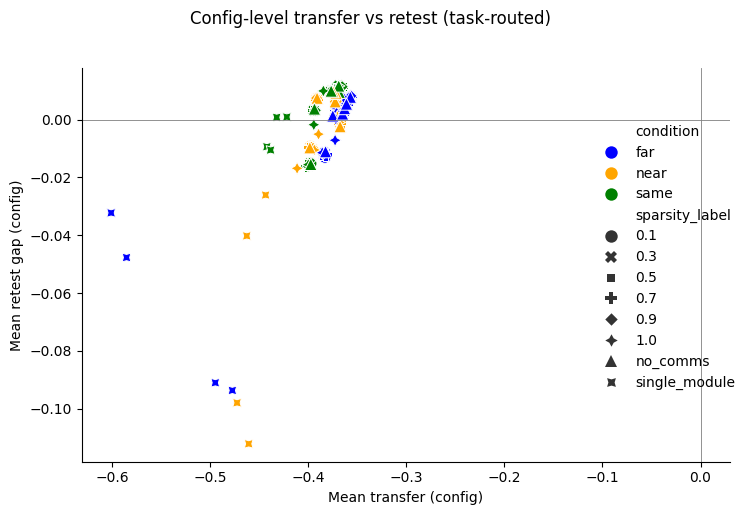

In [10]:
if interf_df.empty:
    print("No data.")
else:
    agg = (
        interf_df.groupby(
            ["sparsity_label", "init_scale", "condition"],
            as_index=False,
        )
        .agg(
            mean_transfer=("transfer_error_diff", "mean"),
            mean_retest=("retest_gap_meanA2", "mean"),
            n=("participant", "count"),
        )
    )
    g = sns.relplot(
        data=agg,
        x="mean_transfer",
        y="mean_retest",
        hue="condition",
        palette=SIMILARITY_PALETTE,
        style="sparsity_label",
        s=80,
        height=5,
        aspect=1.2,
    )
    g.ax.axhline(0, color="gray", lw=0.6)
    g.ax.axvline(0, color="gray", lw=0.6)
    g.set_axis_labels("Mean transfer (config)", "Mean retest gap (config)")
    g.fig.suptitle("Config-level transfer vs retest (task-routed)", y=1.02)
    plt.tight_layout()
    plt.show()